# RANDOM FOREST REGRESSOR

Goal: beat the best  model 
mae = 18600
rmse = 23400

In [45]:
#Data manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

### **1.Data sanity check & data processing**

In [46]:
df = pd.read_pickle(r"C:\Users\fymatamton\Downloads\datasetss\apartment.pkl")

In [47]:
df.head(3) #here price_euro is the prediction part and others are features of it.

,price_euro,rooms,size,bathrooms,terrace,pass_through,finished,height_pos,neighbourhood,year_built,zone
0,133425,2,53.0,1,1,False,not finished,0.17,Intre Lacuri,2024,other
1,168675,3,67.0,2,2,False,not finished,0.17,Intre Lacuri,2024,other
2,177825,3,69.0,2,2,False,not finished,0.17,Intre Lacuri,2024,other


In [48]:
df.shape

(161, 11)

In [49]:
df.dtypes

price_euro         int64
rooms              int64
size             float64
bathrooms          int64
terrace            int64
pass_through        bool
finished          object
height_pos       float64
neighbourhood     object
year_built         int32
zone              object
dtype: object

In [50]:
#lower casing the valeus
df.neighbourhood = df.neighbourhood.str.lower()
df.finished = df.finished.str.lower()
df.zone = df.zone.str.lower()

In [51]:
le = LabelEncoder()#initialising labelencoder
#apply method fit transform on our variables inorder to encode them into numerical values
df.neighbourhood = le.fit_transform(df.neighbourhood)
df.finished = le.fit_transform(df.finished)
df.zone = le.fit_transform(df.zone)

In [52]:
df.head()

,price_euro,rooms,size,bathrooms,terrace,pass_through,finished,height_pos,neighbourhood,year_built,zone
0,133425,2,53.0,1,1,False,3,0.17,8,2024,1
1,168675,3,67.0,2,2,False,3,0.17,8,2024,1
2,177825,3,69.0,2,2,False,3,0.17,8,2024,1
3,168675,3,67.0,2,2,False,3,0.17,5,2024,1
4,133725,2,53.0,1,0,True,3,0.17,8,2024,1


In [53]:
df.dtypes

price_euro         int64
rooms              int64
size             float64
bathrooms          int64
terrace            int64
pass_through        bool
finished           int64
height_pos       float64
neighbourhood      int64
year_built         int32
zone               int64
dtype: object

In [54]:
#converting those three features into catogerical because they are actually numarical labels which encodes categories
#so the lower casing values are convetng into categorical values
df.neighbourhood = df.neighbourhood.astype("category")
df.finished = df.finished.astype("category")
df.zone = df.zone.astype("category")

In [55]:
df.dtypes

price_euro          int64
rooms               int64
size              float64
bathrooms           int64
terrace             int64
pass_through         bool
finished         category
height_pos        float64
neighbourhood    category
year_built          int32
zone             category
dtype: object

In [56]:
df.head()#so the same time they are categorical but numerical value
#here finished pre-processing of data

,price_euro,rooms,size,bathrooms,terrace,pass_through,finished,height_pos,neighbourhood,year_built,zone
0,133425,2,53.0,1,1,False,3,0.17,8,2024,1
1,168675,3,67.0,2,2,False,3,0.17,8,2024,1
2,177825,3,69.0,2,2,False,3,0.17,8,2024,1
3,168675,3,67.0,2,2,False,3,0.17,5,2024,1
4,133725,2,53.0,1,0,True,3,0.17,8,2024,1


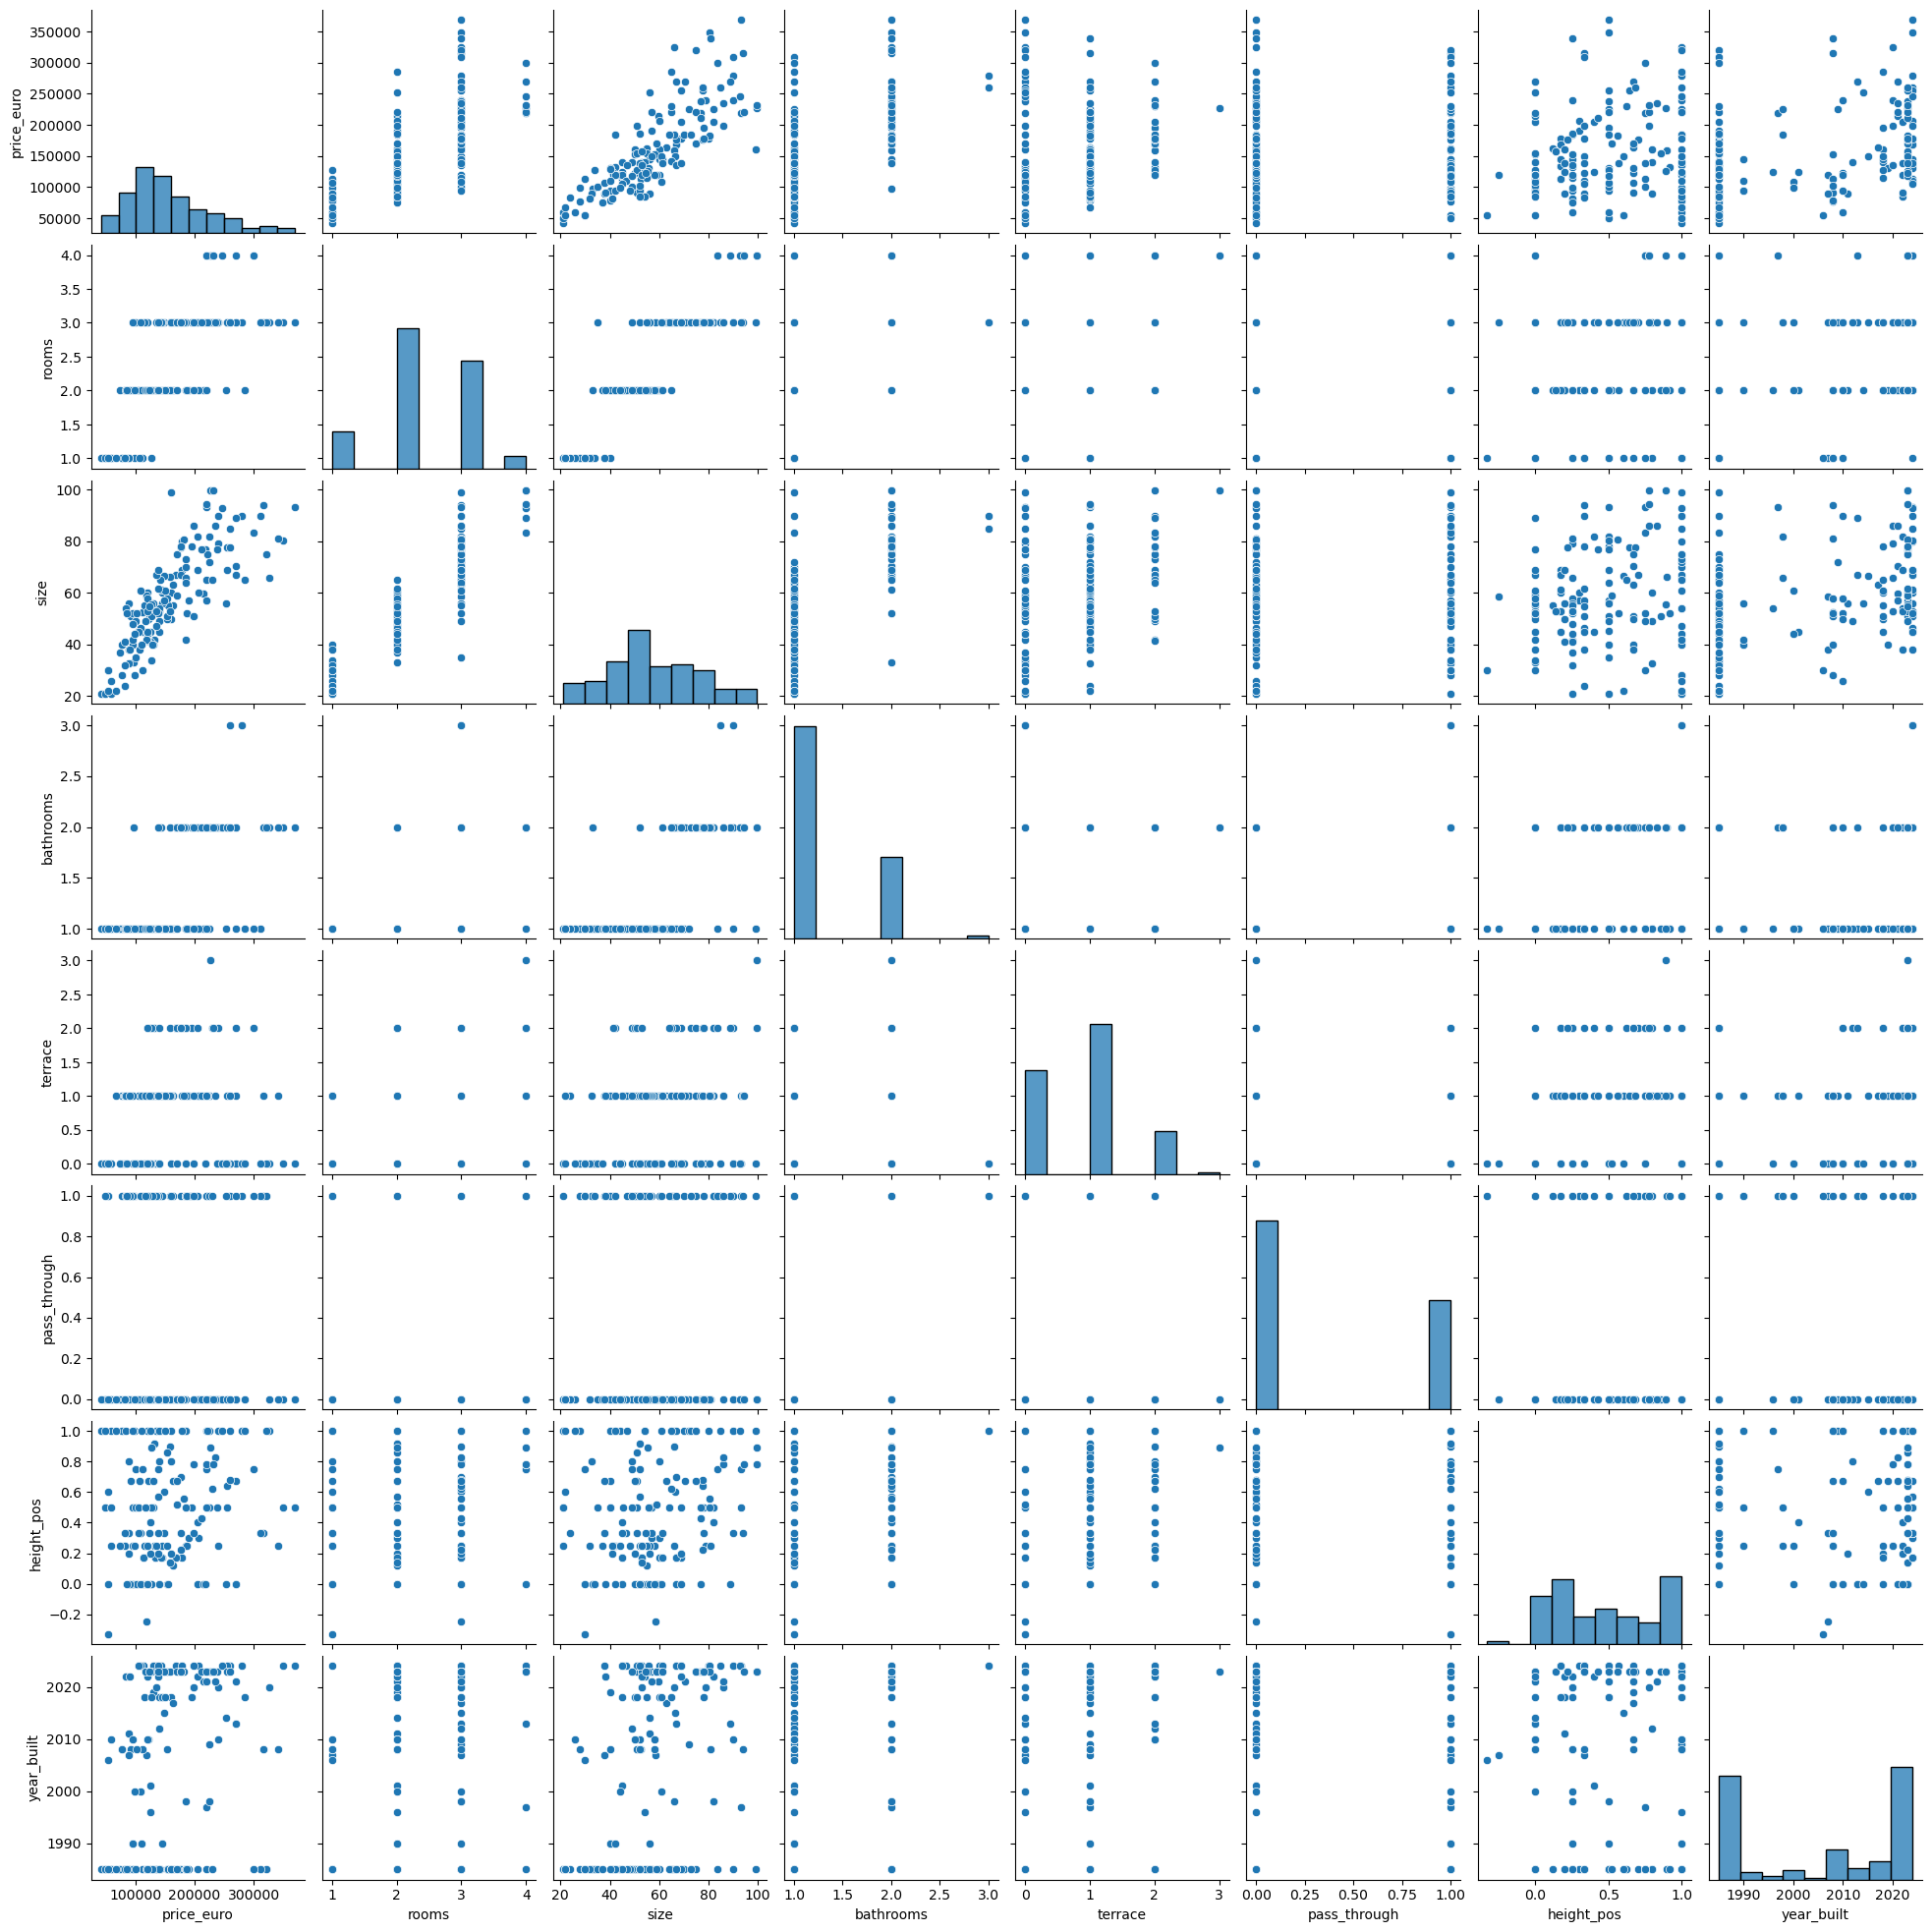

In [57]:
sns.pairplot(df)

<Axes: >

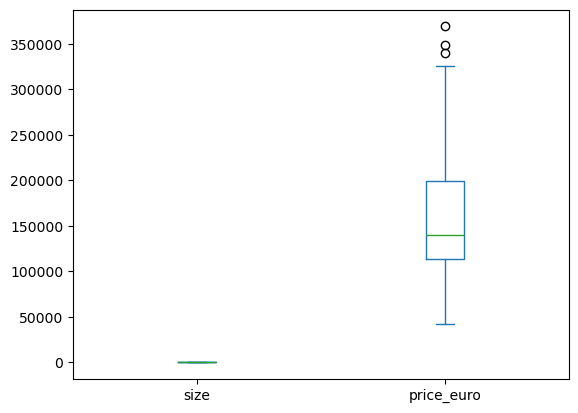

In [58]:
#pairplotted to check if there is a potential of being outliers for any ddta points
#so to double check that use box plot
df[['size', 'price_euro']].plot(kind = 'box')

In [59]:
#it shows 3 points have the potential of being outliers
#those are the points representing very expensive flats
#now eliminate those points from the dataset
df.price_euro.sort_values() #sort values in ascending order so we can see
#the last three values are the three outliers

53      42000
35      49900
210     49900
124     55000
123     55000
        ...  
92     320000
79     325000
264    340000
224    349000
226    369000
Name: price_euro, Length: 161, dtype: int64

In [60]:
df[(df["size"]>95) & (df["price_euro"]<200000)]

,price_euro,rooms,size,bathrooms,terrace,pass_through,finished,height_pos,neighbourhood,year_built,zone
121,161000,3,99.0,1,0,True,0,1.0,2,1985,1


In [61]:
df = df.drop(121)

In [62]:
#elimintating values
log_out = list(df.price_euro.sort_values()[-3:].index)
top_outliers
#those three now belongs to this very priced apartments
df = df.drop(log_out)

In [64]:
df["price_euro_lg"] = np.log(df["price_euro"])

### **2.Generate train - test sets**

In [65]:
#response variable here is price in euro
y = df.price_euro
#cols i wanto use as predictors
#start with all the variable and exclude the if they are not that imp for predn or we can try 
#to start with lower number of variable and then try to imrpove the model by adding one variable at a time
#here try the first method
x = df[['rooms', 'size', 'bathrooms','height_pos', 'neighbourhood', 'year_built']]

In [66]:
#splitting x and y into two sets, the trining set and testing set
from sklearn.model_selection import train_test_split

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=4) #means 10%from dataset will be presented for the test

In [68]:
len(y_test) #16 observatn for testing

16

### **3.Modeling & Hyper-parameter tuning**

In [69]:
#the idea behind random forest is to build multiple small models and aggregate the results 
#from those models inorder to improve overall accuracy and robustness of predictor

In [70]:
model = RandomForestRegressor(n_estimators = 500, max_features = 3, max_samples = 60, oob_score=True )#bootstrpping #maxfeatures: selecting features from no of predictor
#max_samples: num of observation
rf = model.fit(x_train, y_train)

In [71]:
#to check the goodness of fit of rf regressor
#oob = out of bag
print(f'OOB Score: {rf.oob_score_}')

OOB Score: 0.6938758104213287


### **4.Variable Importance**

<Axes: >

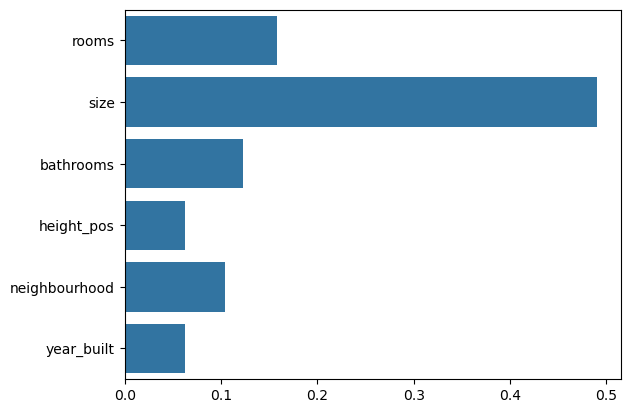

In [72]:
sns.barplot(x = rf.feature_importances_, y = rf.feature_names_in_)

### **Performance Evaluation**

In [73]:
#evaluate performance on of our model on new unseen data set
pred_price = rf.predict(x_test)
#y_test

In [74]:
#comparing predicted and real price of apartments
mae = mean_absolute_error(y_true =np.exp(y_test), y_pred = np.exp(pred_price))
print(f"MAE:{mae}")

mse = mean_squared_error(y_true =np.exp( y_test), y_pred =np.exp (pred_price))
rmse = math.sqrt(mse)
print(f"RMSE: {rmse}")

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\fymatamton\AppData\Local\Temp\ipykernel_21052\2962517398.py:2: RuntimeWarning: overflow encountered in exp
  mae = mean_absolute_error(y_true =np.exp(y_test), y_pred = np.exp(pred_price))


ValueError: Input contains infinity or a value too large for dtype('float64').

In [75]:
#comparing predicted and real price of apartments
mae = mean_absolute_error(y_true = y_test, y_pred = pred_price)
print(f"MAE:{mae}")

mse = mean_squared_error(y_true = y_test, y_pred = pred_price)
rmse = math.sqrt(mse)
print(f"RMSE: {rmse}")

MAE:25780.303999999996
RMSE: 38280.3512807863


In [ ]:
#remove the variable (feature) from above code which are not important
#x = df[[rooms', 'size', 'bathrooms','neighbourhood', 'year_built']]
#from this remove =  'terrace', 'pass_through', 'finished','height_pos','zone'


In [ ]:
fix, ax = plt.subplots(figsize = (10,5))
# Reference line (perfect prediction: actual = predicted)
sns.scatterplot(x=np.exp(y_test), y=np.exp(y_test), ax=ax, color="red", label="Perfect Prediction")

# Actual vs Predicted
sns.scatterplot(x=np.exp(y_test), y=np.exp(pred_price), ax=ax, alpha=0.6, label="Predicted")

ax.set_xlabel("Actual Price (Log Scale)")
ax.set_ylabel("Predicted Price (Log Scale)")
ax.set_title("Actual vs Predicted Apartment Prices")
ax.legend()

plt.show()

In [ ]:
test_df = df.loc[list(y_test.index)]
test_df